# Suppport Vector Machine 

### Task 1: Exploratory Data Analysis (EDA)

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [66]:
#Shape of DataSet
df.shape

(500, 6)

In [67]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [68]:
#Summary Stastistics
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [69]:
#Cheking Missing Values 
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [70]:
##No missing values present in data set

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
# no duplicates  present in dataset

#### Histogram

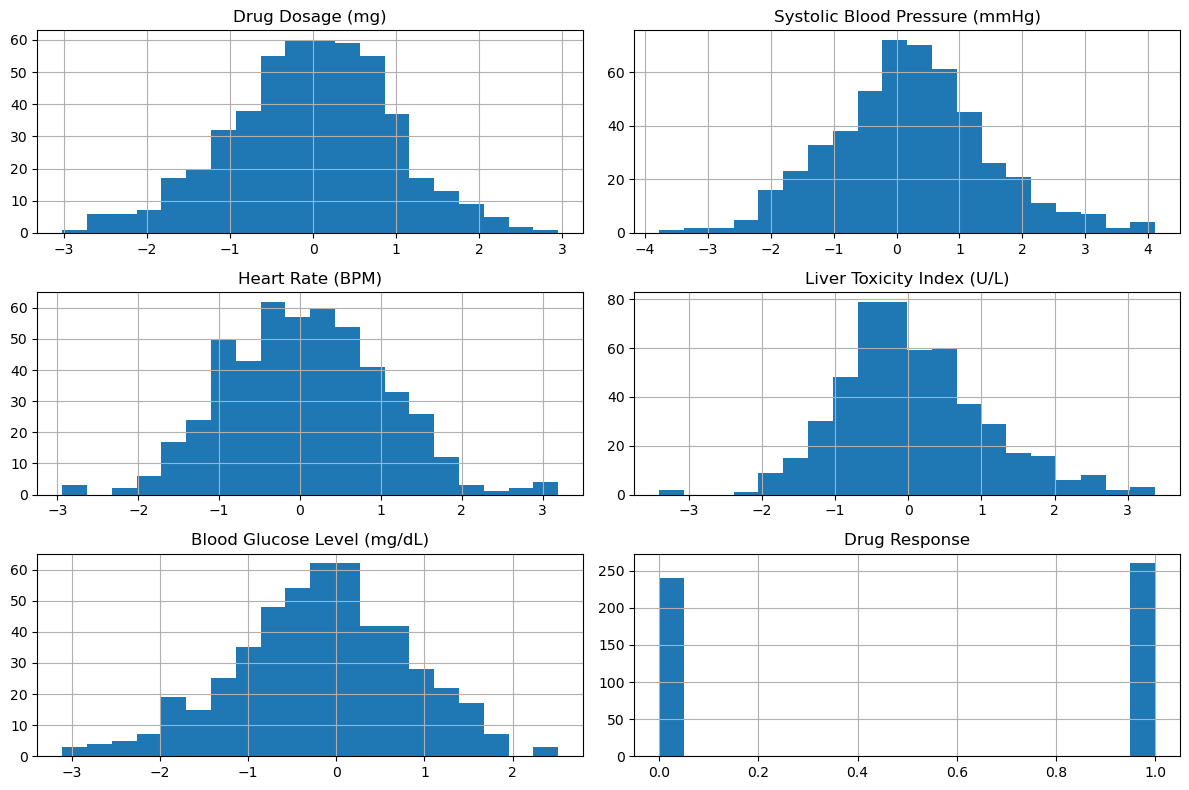

In [73]:
df.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

In [74]:
# Inference : Most numerical features are approximately normally distributed.

### Box Plots

### Density PLots

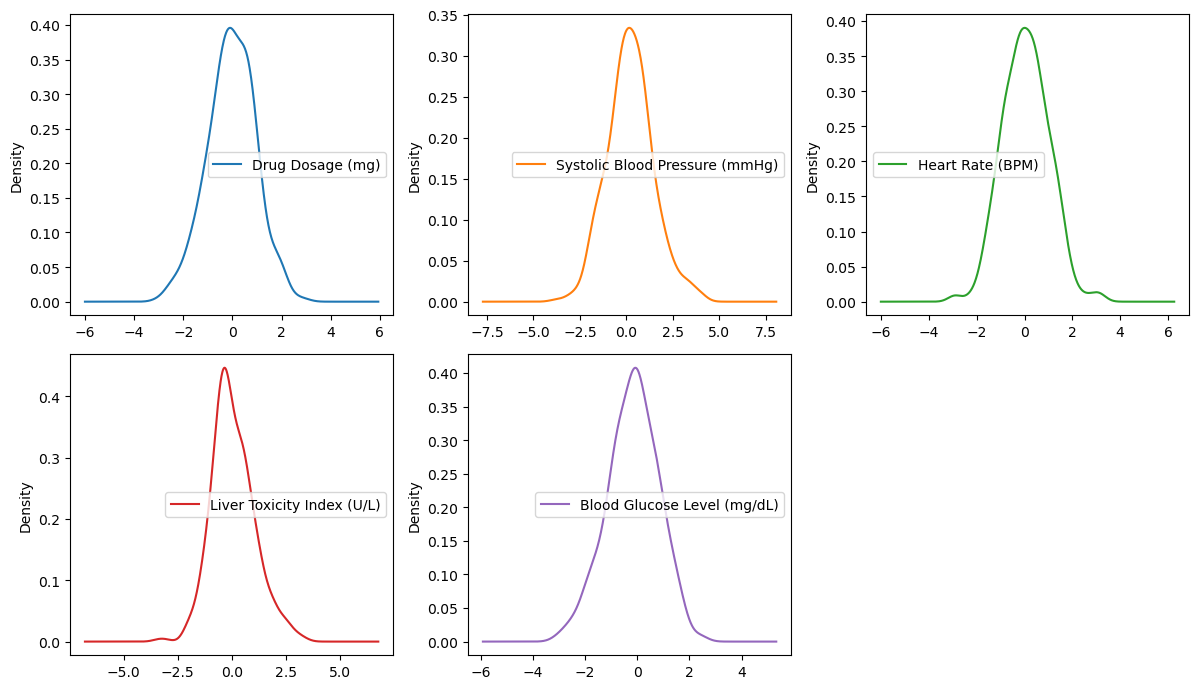

In [75]:
df.iloc[:,:-1].plot(kind='density',
                    subplots=True,
                    layout=(2,3),
                    figsize=(12,7),
                    sharex=False)

plt.tight_layout()
plt.show()

# Correlation Heatmap

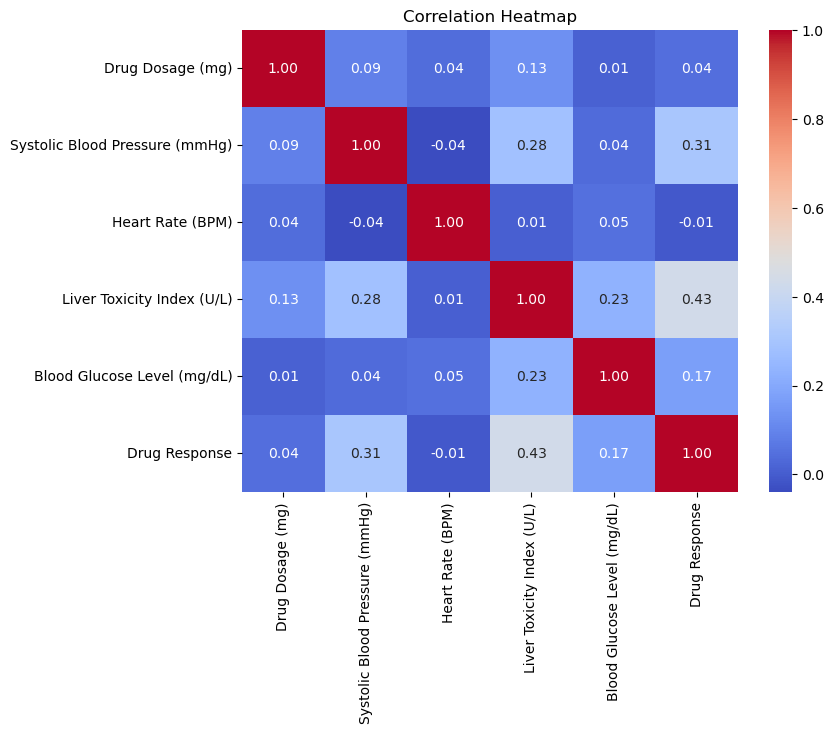

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

#### Observation:
- The heatmap shows relationships between numerical variables.
- Features with high positive or negative correlations may influence drug response.

### Class Distribution 

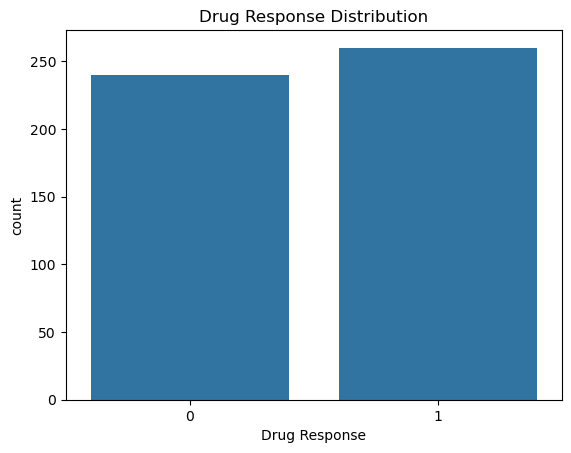

In [77]:
sns.countplot(x='Drug Response', data=df)

plt.title("Drug Response Distribution")

plt.show()

#### Infererence:
- The count plot shows whether the dataset is balanced or imbalanced.
- A nearly equal number of samples in both classes indicates a balanced dataset.

# Task 2: Data Preprocessing 

In [78]:
#This dataset contains only numerical features, no encoding is required.

In [79]:
# 1. Separate Features and Target
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

In [80]:
#2. Train-Test Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 3. Standard Scaling

Since SVM is a distance-based algorithm, feature scaling is very important

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Task 3: Data Visualization

#### Scatter Plot

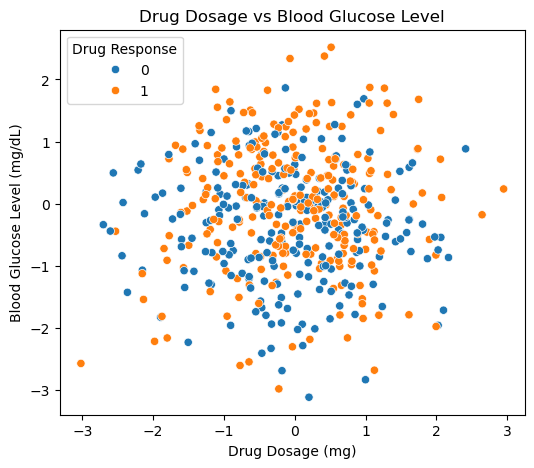

In [82]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='Drug Dosage (mg)',
    y='Blood Glucose Level (mg/dL)',
    hue='Drug Response',
    data=df
)

plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

#### Pair Plot

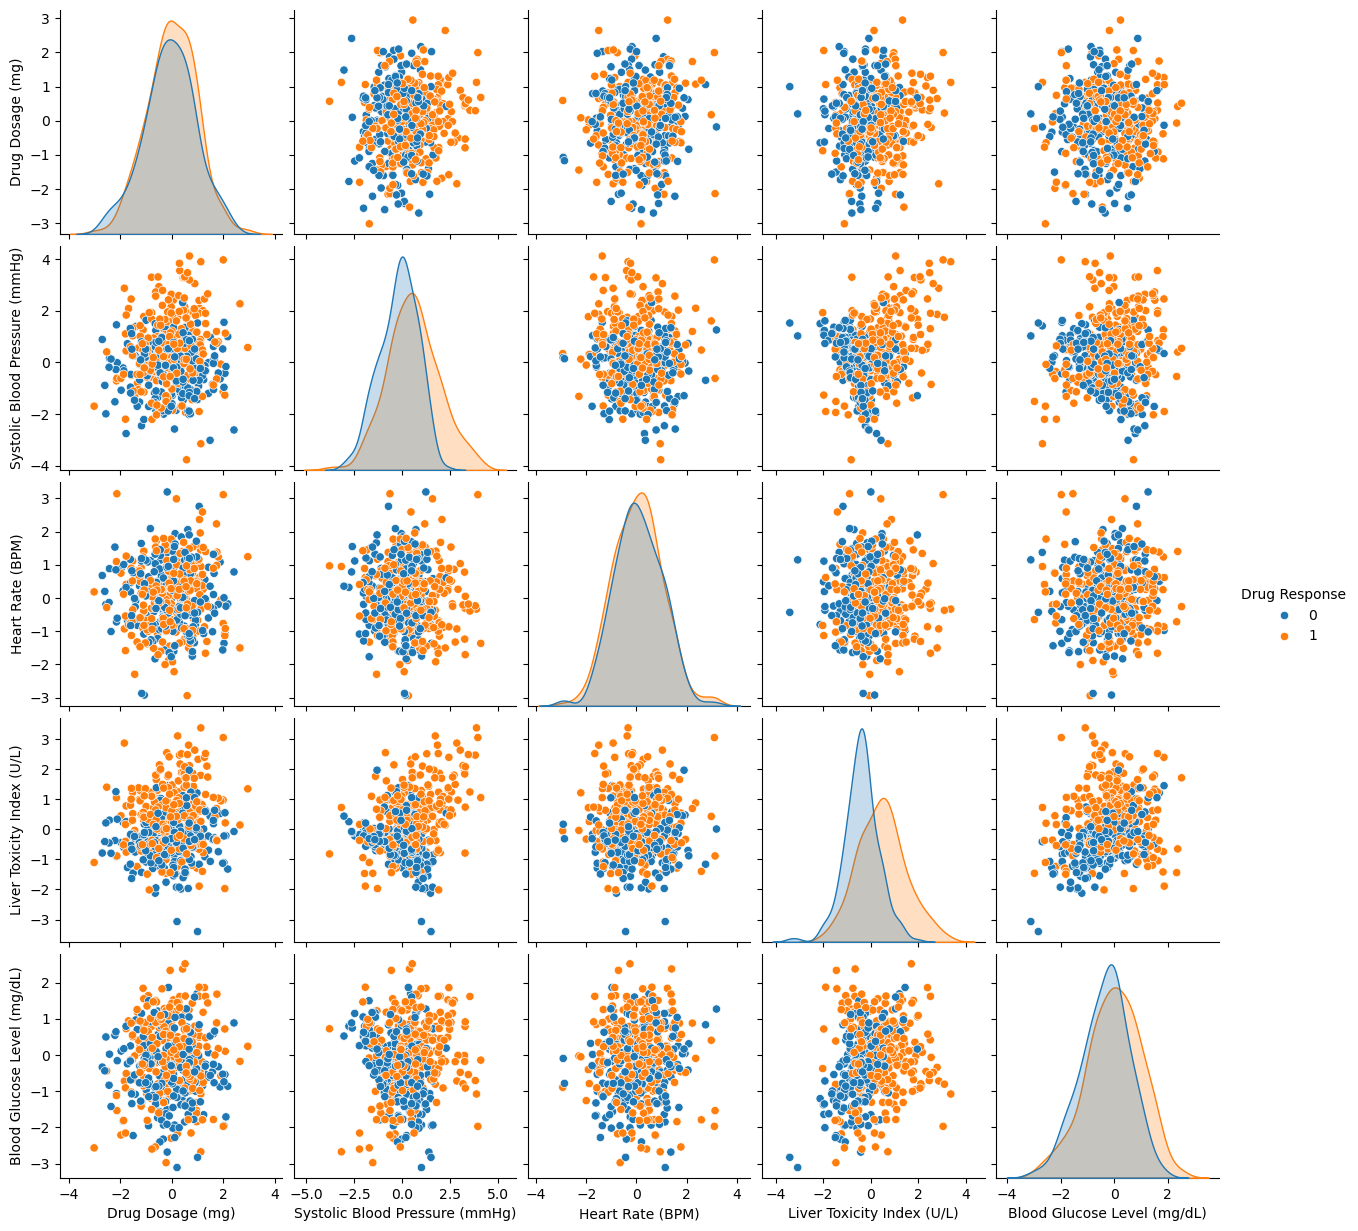

In [83]:
sns.pairplot(df, hue='Drug Response')

plt.show()

### Class Distributions

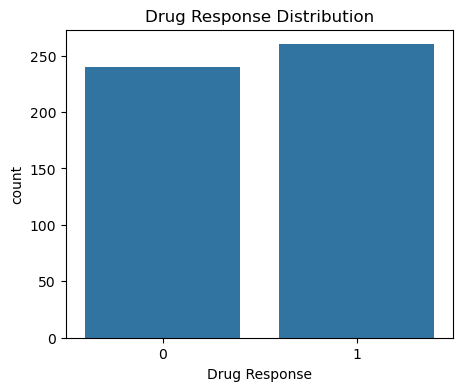

In [84]:
plt.figure(figsize=(5,4))

sns.countplot(x='Drug Response', data=df)

plt.title("Drug Response Distribution")
plt.show()

#### Infernece:
Histogram – Inference:
- Histograms show the distribution of each numerical feature.
- Most features are approximately normally distributed.
- Some features have slight skewness due to extreme values.

Pair Plot – Inference:
- Pair plots show relationships between every pair of features.
- Some features show partial separation between the two drug response classes.
- he diagonal plots display the distribution of each feature.

Scatter Plot (Drug Dosage vs Blood Glucose)
- The scatter plot shows the relationship between drug dosage and blood glucose level.
- The two drug response classes overlap in some regions.
- There is no strong linear relationship between the variables.

Count Plot (Class Distribution)
- The count plot shows the number of patients in each drug response class.
- The dataset appears balanced if both classes have similar counts.
- Both classes have sufficient samples for model training.
- This is suitable for building an SVM classifier.



# Task 4: SVM Implementation

In [85]:
from sklearn.svm import SVC

In [86]:
svm_model = SVC(
    kernel='rbf',
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Evaluation 

In [87]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

In [88]:
def plot_roc(y,yhat):

    fpr,tpr, thresh = roc_curve(y, yhat)
    auc = roc_auc_score(y, yhat)
    print(f'AUC: {auc}')
    
    plt.figure(figsize=(3,3))
    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')
    
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1], 'o--')
    plt.show()

In [89]:
def eval_clf(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(2,2))
    sns.heatmap(cm, cbar=False, annot=True, fmt='d')
    plt.show()
    print(classification_report(y,yhat))

    pre = precision_score(y,yhat)
    rec = recall_score(y,yhat)
    acc = accuracy_score(y,yhat)
    f1 = f1_score(y,yhat)

    print(f'Precision: {pre}\nRecall: {rec}\nAccuracy:{acc}\nF1_score:{f1}')
    
    plot_roc(y,yhat)

# On Training Data

Training Performance


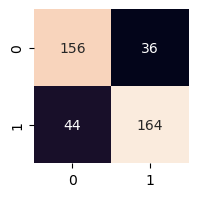

              precision    recall  f1-score   support

           0       0.78      0.81      0.80       192
           1       0.82      0.79      0.80       208

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400

Precision: 0.82
Recall: 0.7884615384615384
Accuracy:0.8
F1_score:0.803921568627451
AUC: 0.8004807692307693


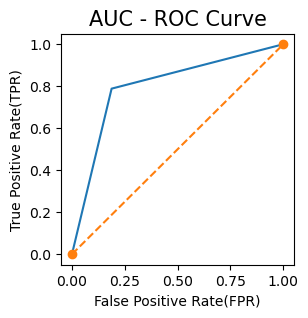

In [90]:
yhat_train = svm_model.predict(X_train)
print("Training Performance")
eval_clf(y_train, yhat_train)

# Task 5: Visualization of SVM Results On Testing Data

Testing Performance


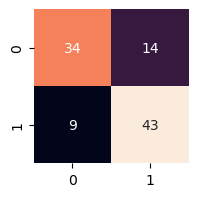

              precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100

Precision: 0.7543859649122807
Recall: 0.8269230769230769
Accuracy:0.77
F1_score:0.7889908256880734
AUC: 0.767628205128205


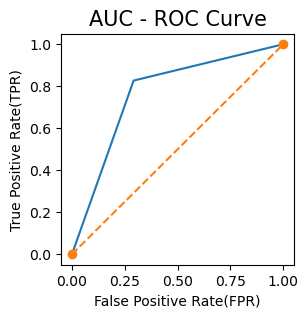

In [91]:
yhat_test = svm_model.predict(X_test)
print("Testing Performance")
eval_clf(y_test, yhat_test)

#### Actual vs Predicted 

In [92]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': yhat_test
})

results.head(10)

,Actual,Predicted
122,1,1
161,0,1
475,1,1
405,0,0
101,0,0
185,1,1
170,0,1
459,0,0
324,1,1
192,1,1


##### Count Plot of Predictions

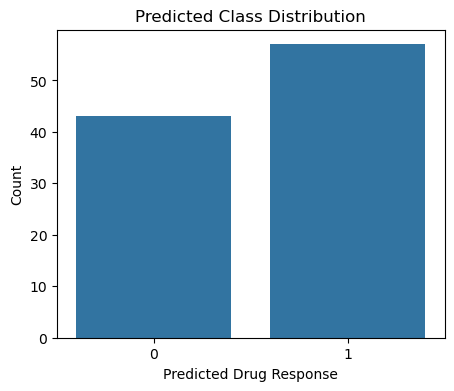

In [93]:
plt.figure(figsize=(5,4))

sns.countplot(x=yhat_test)

plt.xlabel("Predicted Drug Response")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.show()

# Task 6: Parameter Tuning and Optimization

## Using different kernels

In [94]:
# Linear Kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
linear_acc = accuracy_score(y_test, y_pred_linear)
print("Linear Kernel Accuracy:", linear_acc)

Linear Kernel Accuracy: 0.72


In [95]:
#polynomial kernel 
svm_poly = SVC(
    kernel='poly',
    degree=3,
    probability=True,
    random_state=42
)

svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
poly_acc = accuracy_score(y_test, y_pred_poly)
print("Polynomial Kernel Accuracy:", poly_acc)

Polynomial Kernel Accuracy: 0.65


In [96]:
# rbf kernel 
svm_rbf = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
rbf_acc = accuracy_score(y_test, y_pred_rbf)
print("RBF Kernel Accuracy:", rbf_acc)

RBF Kernel Accuracy: 0.77


### comparing kernels

In [97]:
comparison = pd.DataFrame({
    'Kernel':['Linear','Polynomial','RBF'],
    'Accuracy':[linear_acc, poly_acc, rbf_acc]
})
comparison

,Kernel,Accuracy
0,Linear,0.72
1,Polynomial,0.65
2,RBF,0.77


# Hyperparameter Tuning

In [98]:
from sklearn.model_selection import GridSearchCV

In [111]:
params ={
'C': [0.3,0.5,0.7,1.0],
'gamma' : [1,2,3,4]
}


In [112]:
grid = GridSearchCV(estimator=svm_model, cv=5, param_grid=params, scoring='accuracy' )
grid. fit(X_train,y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.3, 0.5, ...], 'gamma': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.7


In [113]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.7, 'gamma': 1}
0.765


# Task 7: Comparison and Analysis

#### Comparing SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [115]:
comparison = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF'],
    'Accuracy': [linear_acc, poly_acc, rbf_acc]
})

comparison

,Kernel,Accuracy
0,Linear,0.72
1,Polynomial,0.65
2,RBF,0.77


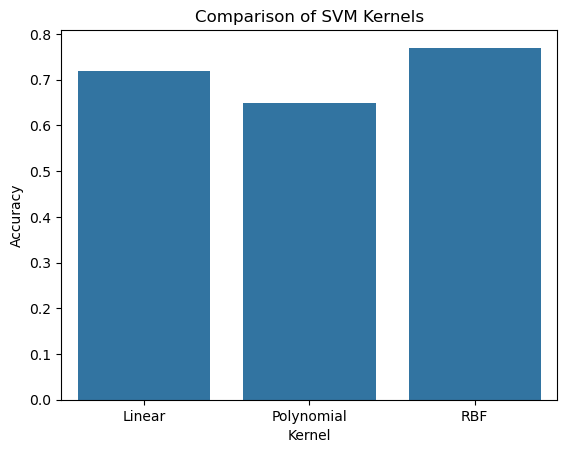

In [116]:
sns.barplot(data=comparison, x='Kernel', y='Accuracy')
plt.title("Comparison of SVM Kernels")
plt.show()